In [2]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt

In [3]:
#rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny

path = "./data/newyorker_caption_contest/data/"
dirs = os.listdir(path)
files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i))]


df = pd.DataFrame()

for file in files:
    
    data = pd.read_csv(file, sep=',')
    data['contest_id'] = os.path.split(file)[-1]
    df = pd.concat([df, data])

df['contest_id'] = df['contest_id'].str.replace('.csv', '')  # Remove '.csv' from values
df.info()
print(data.head())

<class 'pandas.core.frame.DataFrame'>
Index: 2292678 entries, 0 to 4957
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   rank            float64
 1   caption         object 
 2   mean            float64
 3   precision       float64
 4   votes           int64  
 5   not_funny       int64  
 6   somewhat_funny  int64  
 7   funny           int64  
 8   contest_id      object 
dtypes: float64(3), int64(4), object(2)
memory usage: 174.9+ MB
                                             caption      mean  precision  \
0  Do you think death rays would be considered el...  1.632287   0.012004   
1                    Oh sure, now you look at a map.  1.632171   0.018294   
2                I've never heard of planet fitness.  1.626694   0.017874   
3  Wait, was it "conquer the mall" or "conquer th...  1.624266   0.020087   
4                          To Bed, Bath, and Beyond!  1.620504   0.013953   

   votes  not_funny  somewhat_funny  funny contest

In [ ]:
###OLD--->not used anymore
# Assuming 'df' is your DataFrame
df_filtered = df[df['contest_id'] == "510"]

# Creating the scatter plot
df_filtered.plot(kind='scatter', x='rank', y='votes', title='Votes vs. Rank', xlabel='Rank', ylabel='Votes')

# Show the plot
plt.show()


###next cell
# Scatter plot for "not funny" votes
plt.scatter(df_filtered['rank'], df_filtered['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_filtered['rank'], df_filtered['funny'], color='blue', label='Funny', alpha=0.6)


# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

In [ ]:
###OLD code--->not used anymore

women_count = df['caption'].str.contains('women').sum()

#print(df_filtered['caption'].str.contains('women').sum())

men_count = df['caption'].str.contains('men').sum() - women_count

dino_count = df['caption'].str.contains('dino').sum()

witch_count = df['caption'].str.contains('witch').sum()


fig, ax = plt.subplots()

words = ['women',  'dino', 'witch'] #had to remove men, cause its so much more
counts = [women_count, dino_count, witch_count]


ax.bar(words, counts)

ax.set_ylabel('mentioned')
ax.set_title('Who')


plt.show()



In [ ]:
#word list to filter for certain toipcs:
women_filter = "women|girl|mother|wife"  #words that imply a women appeared in the caption text (note: without pronouns cause we search explicit mentions)
men_filter = "men|boy|father|husband" #words that imply a men appear in the caption text (note: substract women_filter to avoid havind the cound for the word woMEN)
dino_filter = "dino|rex"
witch_filter = "witch|enchantress"



coutdict = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "trump": "trump|donald|president"
}

def do_counts(caption_array = df['caption'].copy(), who_count = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress"
}):
    #Count the words in all the captions of all the comics
    counted_dic = who_count.copy()
    counted = []
    for key, value in counted_dic.items():
        counted_dic[key] = (caption_array.str.contains(value).sum())
        counted.append(counted_dic[key])
    return counted

print(do_counts(df['caption'].copy(), coutdict))


[22892, 86116, 1987, 3292, 2985]


In [115]:
coutdict = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "trump": "trump|donald|president"
}

###Analyse the mentions over time

#find all IDs:
ids = np.array(df['contest_id'].copy().drop_duplicates())
all_counts = []

for i in range(len(ids)-1):
    df_ID = df[df['contest_id'] == str(ids[i])]
    all_counts.append(do_counts(df_ID['caption'].copy(), coutdict))
    
print(all_counts)

[[np.int64(86), np.int64(126), np.int64(2), np.int64(3), np.int64(12)], [np.int64(120), np.int64(125), np.int64(1), np.int64(39), np.int64(4)], [np.int64(53), np.int64(124), np.int64(0), np.int64(0), np.int64(2)], [np.int64(30), np.int64(159), np.int64(5), np.int64(9), np.int64(9)], [np.int64(16), np.int64(146), np.int64(1), np.int64(7), np.int64(5)], [np.int64(25), np.int64(145), np.int64(0), np.int64(11), np.int64(7)], [np.int64(113), np.int64(240), np.int64(0), np.int64(21), np.int64(14)], [np.int64(35), np.int64(280), np.int64(0), np.int64(2), np.int64(2)], [np.int64(24), np.int64(121), np.int64(0), np.int64(8), np.int64(4)], [np.int64(29), np.int64(134), np.int64(0), np.int64(4), np.int64(6)], [np.int64(125), np.int64(160), np.int64(0), np.int64(6), np.int64(2)], [np.int64(73), np.int64(159), np.int64(0), np.int64(14), np.int64(8)], [np.int64(102), np.int64(187), np.int64(0), np.int64(3), np.int64(46)], [np.int64(44), np.int64(81), np.int64(0), np.int64(3), np.int64(3)], [np.int64

In [ ]:
coutdict = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "trump": "trump|donald|president",
  "women_count": "women"
}

###Analyse the mentions over time

#find all IDs:
ids = np.array(df['contest_id'].copy().drop_duplicates())
all_counts = []

for i in range(len(ids)-1):
    df_ID = df[df['contest_id'] == str(ids[i])]
    all_counts.append(do_counts(df_ID['caption'].copy(), coutdict))
print(all_counts)

[[np.int64(86), np.int64(126)], [np.int64(120), np.int64(125)], [np.int64(53), np.int64(124)], [np.int64(30), np.int64(159)], [np.int64(16), np.int64(146)], [np.int64(25), np.int64(145)], [np.int64(113), np.int64(240)], [np.int64(35), np.int64(280)], [np.int64(24), np.int64(121)], [np.int64(29), np.int64(134)], [np.int64(125), np.int64(160)], [np.int64(73), np.int64(159)], [np.int64(102), np.int64(187)], [np.int64(44), np.int64(81)], [np.int64(33), np.int64(91)], [np.int64(79), np.int64(168)], [np.int64(62), np.int64(122)], [np.int64(9), np.int64(188)], [np.int64(42), np.int64(79)], [np.int64(24), np.int64(162)], [np.int64(21), np.int64(83)], [np.int64(43), np.int64(85)], [np.int64(7), np.int64(780)], [np.int64(28), np.int64(244)], [np.int64(83), np.int64(107)], [np.int64(151), np.int64(236)], [np.int64(37), np.int64(317)], [np.int64(33), np.int64(77)], [np.int64(20), np.int64(94)], [np.int64(38), np.int64(285)], [np.int64(146), np.int64(310)], [np.int64(59), np.int64(143)], [np.int64(

379


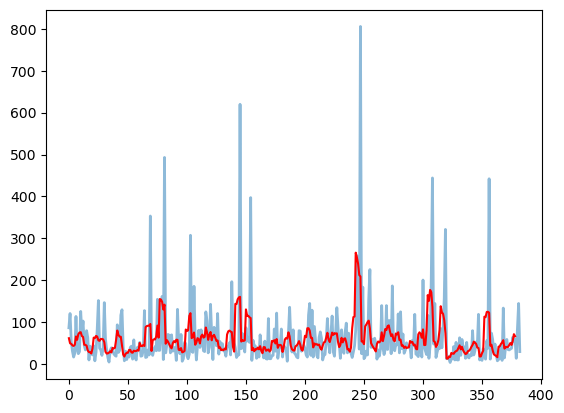

IndexError: index 5 is out of bounds for axis 1 with size 2

In [42]:

men_women_count = np.array(all_counts)


def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

Y11 = men_women_count[:,0]
Y12 = moving_average(Y11,5)
print(len(Y12))
time = np.arange(len(Y11))

plt.plot(np.arange(len(Y11)), Y11,linestyle='-', linewidth=2,alpha=.5)
plt.plot(np.arange(len(Y12)), Y12,color='r')

#plt.axhline(y=np.nanmean(men_women_count))

plt.show()

Y21 = men_women_count[:,1]- men_women_count[:,5]
Y22 = moving_average(Y11,5)
print(len(Y12))
time = np.arange(len(Y11))

plt.plot(np.arange(len(Y21)), Y21,linestyle='-', linewidth=2,alpha=.5)
plt.plot(np.arange(len(Y22)), Y22,color='r')

#plt.axhline(y=np.nanmean(men_women_count))

plt.show()

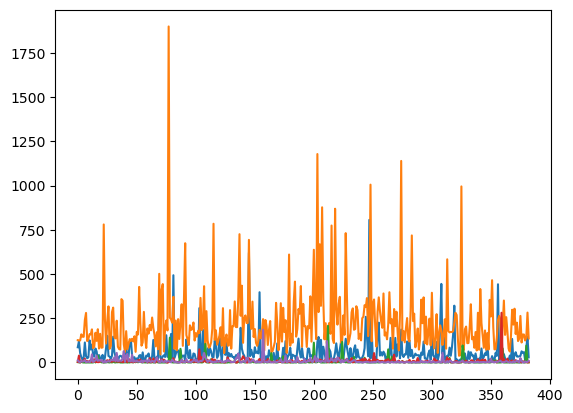

In [ ]:
plt.plot(all_counts)
#all

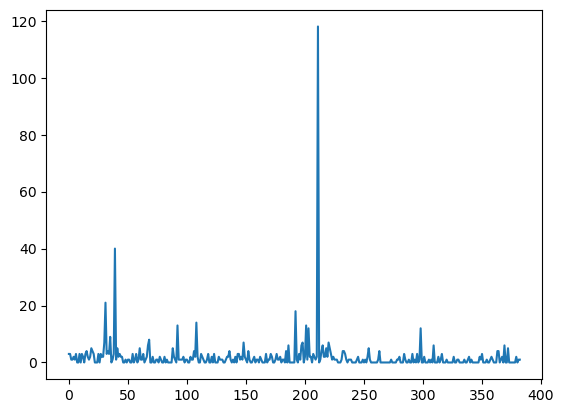

In [ ]:
plt.plot(all_counts)
#trump

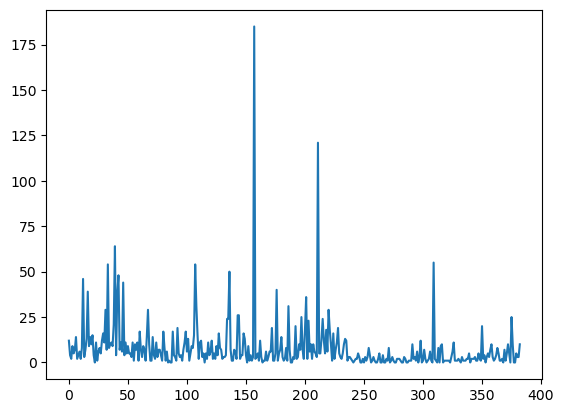

In [ ]:
plt.plot(all_counts)
#trump, president, donald

[22892, 86116, 1987]


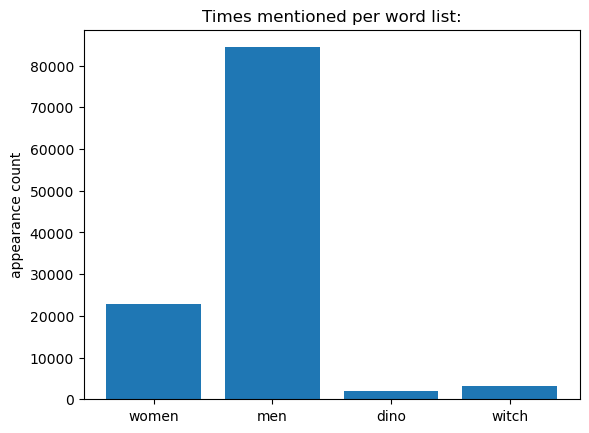

In [13]:
#plot the counts of the wordlist for all the data together as a boxplot
coutdict = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "onlywomen": "women"
}

counts = do_counts(df['caption'].copy(), coutdict)



fig, ax = plt.subplots()

words = ['women',  'men', 'dino', 'witch'] #think about substracting women from men!!!!

print(counts[:3])
counts[1] = counts[1]- counts[4]
ax.bar(words, counts[:4])
ax.set_ylabel('appearance count')
ax.set_title('Times mentioned per word list:')

plt.show()

### Yunos part


In [ ]:
from src.utils.data_utils import count_terms, top_terms, plot_top_terms



top_captions = df.groupby('contest_id', group_keys=False).apply(
    lambda x: x.nlargest(50, 'votes'))
    
top_captions = top_captions['caption'].dropna().astype(str).tolist()




vocab, counts = count_terms(top_captions)
top_vocab, top_counts = top_terms(vocab, counts)
plot_top_terms(top_vocab, top_counts)
